In [9]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from scipy.spatial.distance import cosine, jensenshannon
from sklearn.metrics.pairwise import cosine_similarity

# ============================================================
# 1. Paths
# ============================================================

INPUT_PATH = Path("../results/one_class_neutral_model_results/one_class_neutral_scores_v1.tsv")

OUTPUT_DIR = Path("../results/mutational_spectrum_results")
OUTPUT_DIR.mkdir(exist_ok=True)

GROUPED_OUTPUT = OUTPUT_DIR / "spectrum_groups_from_one_class_T95_v1.tsv"
SPECTRUM_COUNTS_OUTPUT = OUTPUT_DIR / "mutation_spectrum_counts_v1.tsv"
SPECTRUM_FREQ_OUTPUT = OUTPUT_DIR / "mutation_spectrum_frequencies_v1.tsv"
PAIRWISE_OUTPUT = OUTPUT_DIR / "mutation_spectrum_pairwise_distances_v1.tsv"

PLOTS_DIR = OUTPUT_DIR / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

# ============================================================
# 2. Load data
# ============================================================

df = pd.read_csv(INPUT_PATH, sep="\t", low_memory=False)

print("Input shape:", df.shape)
print("\nAnalysis group distribution:")
print(df["analysis_group"].value_counts(dropna=False))

Input shape: (49704, 30)

Analysis group distribution:
analysis_group
unlabeled_or_other            41280
neutral_reference              8284
article_pathogenic_posthoc       84
disease_suspected_posthoc        56
Name: count, dtype: int64


In [2]:
# ============================================================
# 3. Define groups
# ============================================================

work = df.copy()

is_neutral = work["analysis_group"] == "neutral_reference"
is_unlabeled = work["analysis_group"] == "unlabeled_or_other"
is_article = work["analysis_group"] == "article_pathogenic_posthoc"
is_disease = work["analysis_group"] == "disease_suspected_posthoc"

below_T95 = work["isolation_forest_above_T95"] == 0
above_T95 = work["isolation_forest_above_T95"] == 1

below_T99 = work["isolation_forest_above_T99"] == 0
above_T99 = work["isolation_forest_above_T99"] == 1

# Primary groups
work["spectrum_group_primary_T95"] = "exclude"

work.loc[
    is_neutral | (is_unlabeled & below_T95),
    "spectrum_group_primary_T95"
] = "expanded_neutral_like_T95"

work.loc[
    is_unlabeled & above_T95,
    "spectrum_group_primary_T95"
] = "unlabeled_out_of_neutral_domain_T95"

# Strict sensitivity
work["spectrum_group_strict_T95"] = "exclude"

work.loc[
    (is_neutral & below_T95) | (is_unlabeled & below_T95),
    "spectrum_group_strict_T95"
] = "strict_expanded_neutral_like_T95"

work.loc[
    is_unlabeled & above_T95,
    "spectrum_group_strict_T95"
] = "unlabeled_out_of_neutral_domain_T95"

# T99 sensitivity
work["spectrum_group_primary_T99"] = "exclude"

work.loc[
    is_neutral | (is_unlabeled & below_T99),
    "spectrum_group_primary_T99"
] = "expanded_neutral_like_T99"

work.loc[
    is_unlabeled & above_T99,
    "spectrum_group_primary_T99"
] = "unlabeled_out_of_neutral_domain_T99"

# Post-hoc groups
work["spectrum_group_posthoc"] = "exclude"

work.loc[is_neutral, "spectrum_group_posthoc"] = "known_neutral_reference"
work.loc[is_article, "spectrum_group_posthoc"] = "article_pathogenic_posthoc"
work.loc[is_disease, "spectrum_group_posthoc"] = "disease_suspected_posthoc"
work.loc[is_unlabeled & below_T95, "spectrum_group_posthoc"] = "unlabeled_neutral_like_T95"
work.loc[is_unlabeled & above_T95, "spectrum_group_posthoc"] = "unlabeled_out_of_neutral_domain_T95"

print("\nPrimary T95 groups:")
print(work["spectrum_group_primary_T95"].value_counts())

print("\nStrict T95 groups:")
print(work["spectrum_group_strict_T95"].value_counts())

print("\nPrimary T99 groups:")
print(work["spectrum_group_primary_T99"].value_counts())

print("\nPost-hoc groups:")
print(work["spectrum_group_posthoc"].value_counts())


Primary T95 groups:
spectrum_group_primary_T95
expanded_neutral_like_T95              41264
unlabeled_out_of_neutral_domain_T95     8300
exclude                                  140
Name: count, dtype: int64

Strict T95 groups:
spectrum_group_strict_T95
strict_expanded_neutral_like_T95       40860
unlabeled_out_of_neutral_domain_T95     8300
exclude                                  544
Name: count, dtype: int64

Primary T99 groups:
spectrum_group_primary_T99
expanded_neutral_like_T99              47447
unlabeled_out_of_neutral_domain_T99     2117
exclude                                  140
Name: count, dtype: int64

Post-hoc groups:
spectrum_group_posthoc
unlabeled_neutral_like_T95             32980
unlabeled_out_of_neutral_domain_T95     8300
known_neutral_reference                 8284
article_pathogenic_posthoc                84
disease_suspected_posthoc                 56
Name: count, dtype: int64


In [3]:
# ============================================================
# 4. Substitution type
# ============================================================

work["reference"] = work["reference"].astype(str).str.upper()
work["alternate"] = work["alternate"].astype(str).str.upper()

substitution_order_12 = [
    "A>C", "A>G", "A>T",
    "C>A", "C>G", "C>T",
    "G>A", "G>C", "G>T",
    "T>A", "T>C", "T>G",
]

work["substitution_type_12"] = work["reference"] + ">" + work["alternate"]

work["is_valid_snv_substitution"] = work["substitution_type_12"].isin(
    substitution_order_12
).astype(int)

invalid = work[work["is_valid_snv_substitution"] == 0]

print("\nInvalid substitution types:")
print(invalid["substitution_type_12"].value_counts())

work = work[work["is_valid_snv_substitution"] == 1].copy()


Invalid substitution types:
Series([], Name: count, dtype: int64)


In [4]:
# ============================================================
# 5. Spectrum functions
# ============================================================

def compute_spectrum(data, group_col, group_name):
    subset = data[data[group_col] == group_name].copy()

    counts = (
        subset["substitution_type_12"]
        .value_counts()
        .reindex(substitution_order_12)
        .fillna(0)
        .astype(int)
    )

    frequencies = counts / counts.sum() if counts.sum() > 0 else counts * np.nan

    out = pd.DataFrame({
        "substitution_type": substitution_order_12,
        "count": counts.values,
        "frequency": frequencies.values,
    })

    out["group_col"] = group_col
    out["group_name"] = group_name
    out["n_variants"] = int(counts.sum())

    return out


def compute_all_spectra(data, group_col):
    spectra = []

    for group_name in sorted(data[group_col].unique()):
        if group_name == "exclude":
            continue

        spectra.append(
            compute_spectrum(data, group_col, group_name)
        )

    return pd.concat(spectra, axis=0)


def get_frequency_vector(spectrum_df, group_col, group_name):
    sub = spectrum_df[
        (spectrum_df["group_col"] == group_col)
        & (spectrum_df["group_name"] == group_name)
    ].copy()

    sub = sub.set_index("substitution_type").reindex(substitution_order_12)

    return sub["frequency"].values

In [5]:
# ============================================================
# 6. Compute spectra
# ============================================================

group_cols = [
    "spectrum_group_primary_T95",
    "spectrum_group_strict_T95",
    "spectrum_group_primary_T99",
    "spectrum_group_posthoc",
]

all_spectra = []

for group_col in group_cols:
    all_spectra.append(
        compute_all_spectra(work, group_col)
    )

spectrum_df = pd.concat(all_spectra, axis=0)

spectrum_counts = spectrum_df[
    [
        "group_col",
        "group_name",
        "n_variants",
        "substitution_type",
        "count",
    ]
].copy()

spectrum_freq = spectrum_df[
    [
        "group_col",
        "group_name",
        "n_variants",
        "substitution_type",
        "frequency",
    ]
].copy()

spectrum_counts.to_csv(SPECTRUM_COUNTS_OUTPUT, sep="\t", index=False)
spectrum_freq.to_csv(SPECTRUM_FREQ_OUTPUT, sep="\t", index=False)

print("\nSaved:")
print(SPECTRUM_COUNTS_OUTPUT)
print(SPECTRUM_FREQ_OUTPUT)


Saved:
../results/mutational_spectrum_results/mutation_spectrum_counts_v1.tsv
../results/mutational_spectrum_results/mutation_spectrum_frequencies_v1.tsv


In [6]:
# ============================================================
# 7. Pairwise spectrum distances
# ============================================================

pairwise_rows = []

for group_col in group_cols:
    group_names = [
        g for g in sorted(work[group_col].unique())
        if g != "exclude"
    ]

    for i in range(len(group_names)):
        for j in range(i + 1, len(group_names)):
            g1 = group_names[i]
            g2 = group_names[j]

            v1 = get_frequency_vector(spectrum_df, group_col, g1)
            v2 = get_frequency_vector(spectrum_df, group_col, g2)

            cosine_sim = 1 - cosine(v1, v2)
            js_dist = jensenshannon(v1, v2, base=2)

            pairwise_rows.append({
                "group_col": group_col,
                "group_1": g1,
                "group_2": g2,
                "cosine_similarity": cosine_sim,
                "jensen_shannon_distance": js_dist,
            })

pairwise_df = pd.DataFrame(pairwise_rows)

pairwise_df.to_csv(PAIRWISE_OUTPUT, sep="\t", index=False)

print("\nPairwise distances:")
print(pairwise_df)

print("\nSaved:")
print(PAIRWISE_OUTPUT)


Pairwise distances:
                     group_col                           group_1  \
0   spectrum_group_primary_T95         expanded_neutral_like_T95   
1    spectrum_group_strict_T95  strict_expanded_neutral_like_T95   
2   spectrum_group_primary_T99         expanded_neutral_like_T99   
3       spectrum_group_posthoc        article_pathogenic_posthoc   
4       spectrum_group_posthoc        article_pathogenic_posthoc   
5       spectrum_group_posthoc        article_pathogenic_posthoc   
6       spectrum_group_posthoc        article_pathogenic_posthoc   
7       spectrum_group_posthoc         disease_suspected_posthoc   
8       spectrum_group_posthoc         disease_suspected_posthoc   
9       spectrum_group_posthoc         disease_suspected_posthoc   
10      spectrum_group_posthoc           known_neutral_reference   
11      spectrum_group_posthoc           known_neutral_reference   
12      spectrum_group_posthoc        unlabeled_neutral_like_T95   

                          

In [7]:
# ============================================================
# 8. Save grouped table
# ============================================================

grouped_cols = [
    "variant_id",
    "position",
    "reference",
    "alternate",
    "substitution_type_12",
    "validation_label",
    "analysis_group",

    "isolation_forest_outlier_score",
    "isolation_forest_above_T95",
    "isolation_forest_above_T99",

    "spectrum_group_primary_T95",
    "spectrum_group_strict_T95",
    "spectrum_group_primary_T99",
    "spectrum_group_posthoc",
]

work[grouped_cols].to_csv(GROUPED_OUTPUT, sep="\t", index=False)

print("\nSaved grouped table:")
print(GROUPED_OUTPUT)


Saved grouped table:
../results/mutational_spectrum_results/spectrum_groups_from_one_class_T95_v1.tsv


In [10]:
# ============================================================
# 9. Plot settings
# ============================================================

substitution_order_12 = [
    "A>C", "A>G", "A>T",
    "C>A", "C>G", "C>T",
    "G>A", "G>C", "G>T",
    "T>A", "T>C", "T>G",
]

group_label_map = {
    "expanded_neutral_like_T95": "Expanded neutral-like T95",
    "strict_expanded_neutral_like_T95": "Strict expanded neutral-like T95",
    "unlabeled_out_of_neutral_domain_T95": "Out-of-neutral-domain T95",
    "expanded_neutral_like_T99": "Expanded neutral-like T99",
    "unlabeled_out_of_neutral_domain_T99": "Out-of-neutral-domain T99",
    "known_neutral_reference": "Known neutral reference",
    "article_pathogenic_posthoc": "Article pathogenic post-hoc",
    "disease_suspected_posthoc": "Disease suspected post-hoc",
    "unlabeled_neutral_like_T95": "Unlabeled neutral-like T95",
}

# Цвета можно оставить дефолтными, но фиксированный словарь удобен для читаемости.
# Если не хочешь фиксировать цвета, просто убери color=... из plotting functions.
substitution_color_map = {
    "A>C": "#4C72B0",
    "A>G": "#55A868",
    "A>T": "#C44E52",
    "C>A": "#8172B2",
    "C>G": "#CCB974",
    "C>T": "#64B5CD",
    "G>A": "#4C72B0",
    "G>C": "#55A868",
    "G>T": "#C44E52",
    "T>A": "#8172B2",
    "T>C": "#CCB974",
    "T>G": "#64B5CD",
}

In [11]:
# ============================================================
# 10. Single spectrum barplot
# ============================================================

def plot_single_spectrum(
    spectrum_freq,
    group_col,
    group_name,
    output_dir=None,
    show=True,
):
    plot_df = spectrum_freq[
        (spectrum_freq["group_col"] == group_col)
        & (spectrum_freq["group_name"] == group_name)
    ].copy()

    if plot_df.empty:
        raise ValueError(f"No spectrum found for {group_col} = {group_name}")

    plot_df = (
        plot_df
        .set_index("substitution_type")
        .reindex(substitution_order_12)
        .reset_index()
    )

    n_variants = int(plot_df["n_variants"].dropna().iloc[0])

    x = np.arange(len(substitution_order_12))
    y = plot_df["frequency"].values

    plt.figure(figsize=(10, 5))

    plt.bar(
        x,
        y,
        color=[substitution_color_map[s] for s in substitution_order_12],
    )

    plt.xticks(x, substitution_order_12, rotation=45, ha="right")
    plt.ylabel("Frequency")
    plt.xlabel("Substitution type")
    plt.ylim(0, max(y) * 1.2 if np.nanmax(y) > 0 else 1)

    title = group_label_map.get(group_name, group_name)
    plt.title(f"{title}\n{group_col}, n={n_variants}")

    plt.tight_layout()

    if output_dir is not None:
        out_path = output_dir / f"spectrum_{group_col}_{group_name}.png"
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        print("Saved:", out_path)

    if show:
        plt.show()
    else:
        plt.close()

Saved: ../results/mutational_spectrum_results/plots/spectrum_spectrum_group_primary_T95_expanded_neutral_like_T95.png


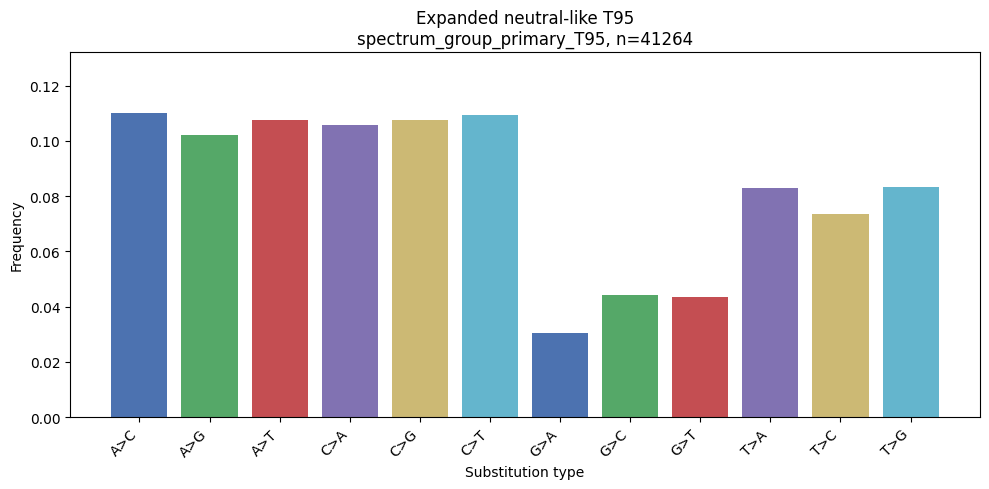

Saved: ../results/mutational_spectrum_results/plots/spectrum_spectrum_group_primary_T95_unlabeled_out_of_neutral_domain_T95.png


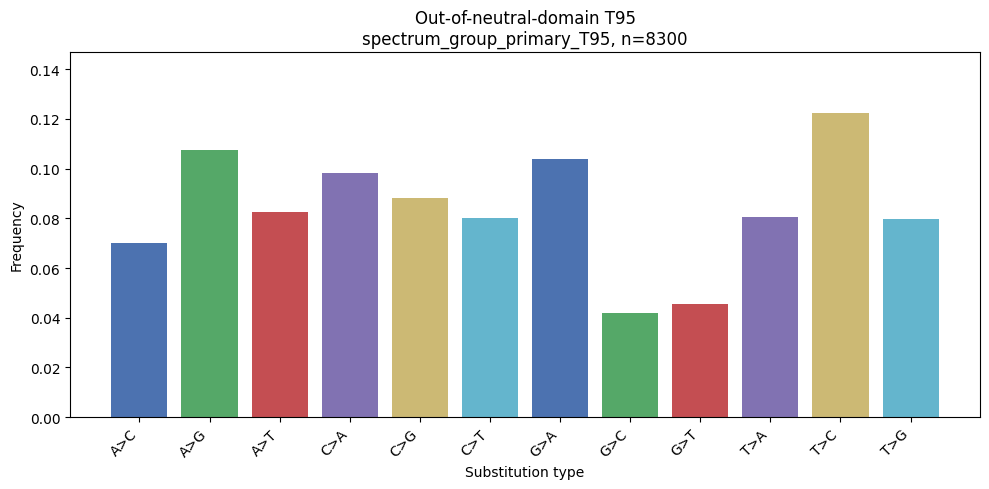

In [12]:
plot_single_spectrum(
    spectrum_freq,
    group_col="spectrum_group_primary_T95",
    group_name="expanded_neutral_like_T95",
    output_dir=PLOTS_DIR,
)

plot_single_spectrum(
    spectrum_freq,
    group_col="spectrum_group_primary_T95",
    group_name="unlabeled_out_of_neutral_domain_T95",
    output_dir=PLOTS_DIR,
)

In [13]:
# ============================================================
# 11. Two-group spectrum comparison
# ============================================================

def plot_two_group_spectrum_comparison(
    spectrum_freq,
    group_col,
    group_1,
    group_2,
    output_dir=None,
    show=True,
):
    df1 = spectrum_freq[
        (spectrum_freq["group_col"] == group_col)
        & (spectrum_freq["group_name"] == group_1)
    ].copy()

    df2 = spectrum_freq[
        (spectrum_freq["group_col"] == group_col)
        & (spectrum_freq["group_name"] == group_2)
    ].copy()

    if df1.empty:
        raise ValueError(f"No spectrum found for {group_col} = {group_1}")

    if df2.empty:
        raise ValueError(f"No spectrum found for {group_col} = {group_2}")

    df1 = df1.set_index("substitution_type").reindex(substitution_order_12)
    df2 = df2.set_index("substitution_type").reindex(substitution_order_12)

    y1 = df1["frequency"].values
    y2 = df2["frequency"].values

    n1 = int(df1["n_variants"].dropna().iloc[0])
    n2 = int(df2["n_variants"].dropna().iloc[0])

    x = np.arange(len(substitution_order_12))
    width = 0.42

    plt.figure(figsize=(12, 5))

    plt.bar(
        x - width / 2,
        y1,
        width=width,
        label=f"{group_label_map.get(group_1, group_1)} (n={n1})",
    )

    plt.bar(
        x + width / 2,
        y2,
        width=width,
        label=f"{group_label_map.get(group_2, group_2)} (n={n2})",
    )

    plt.xticks(x, substitution_order_12, rotation=45, ha="right")
    plt.ylabel("Frequency")
    plt.xlabel("Substitution type")
    plt.title(f"Mutation spectrum comparison\n{group_label_map.get(group_1, group_1)} vs {group_label_map.get(group_2, group_2)}")
    plt.legend(fontsize=8)
    plt.tight_layout()

    if output_dir is not None:
        out_path = output_dir / f"spectrum_comparison_{group_col}_{group_1}_vs_{group_2}.png"
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        print("Saved:", out_path)

    if show:
        plt.show()
    else:
        plt.close()

Saved: ../results/mutational_spectrum_results/plots/spectrum_comparison_spectrum_group_primary_T95_expanded_neutral_like_T95_vs_unlabeled_out_of_neutral_domain_T95.png


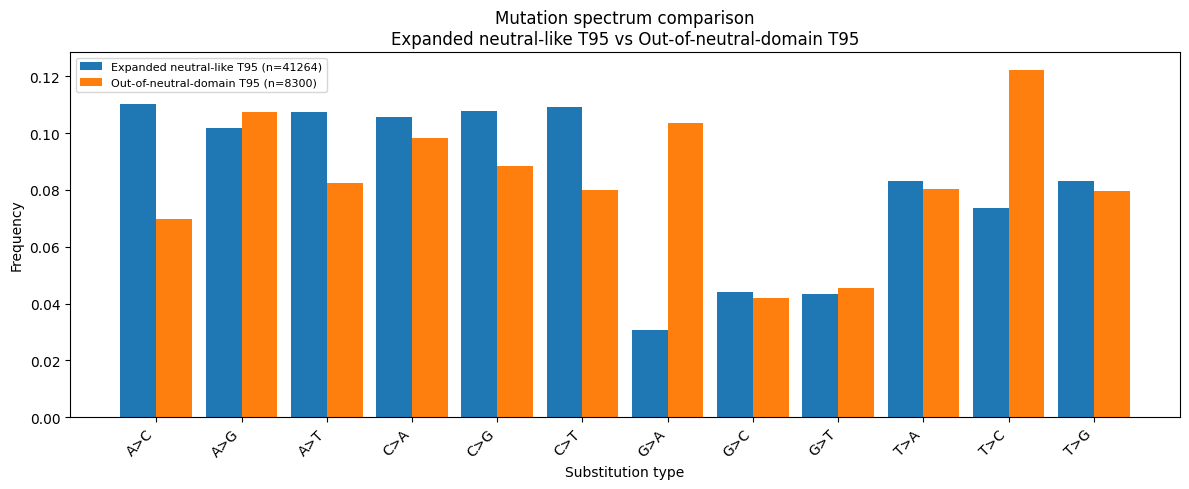

Saved: ../results/mutational_spectrum_results/plots/spectrum_comparison_spectrum_group_strict_T95_strict_expanded_neutral_like_T95_vs_unlabeled_out_of_neutral_domain_T95.png


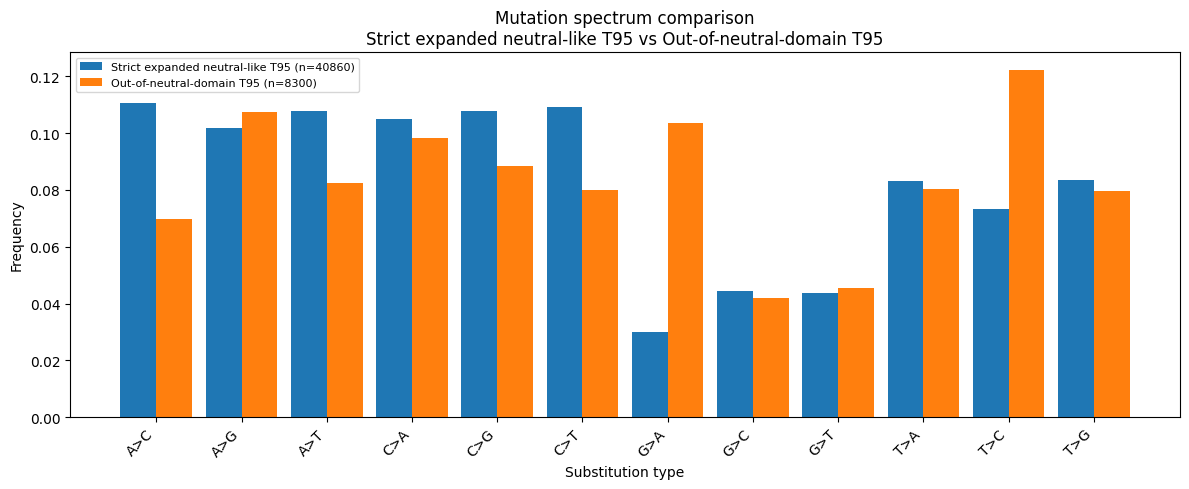

Saved: ../results/mutational_spectrum_results/plots/spectrum_comparison_spectrum_group_primary_T99_expanded_neutral_like_T99_vs_unlabeled_out_of_neutral_domain_T99.png


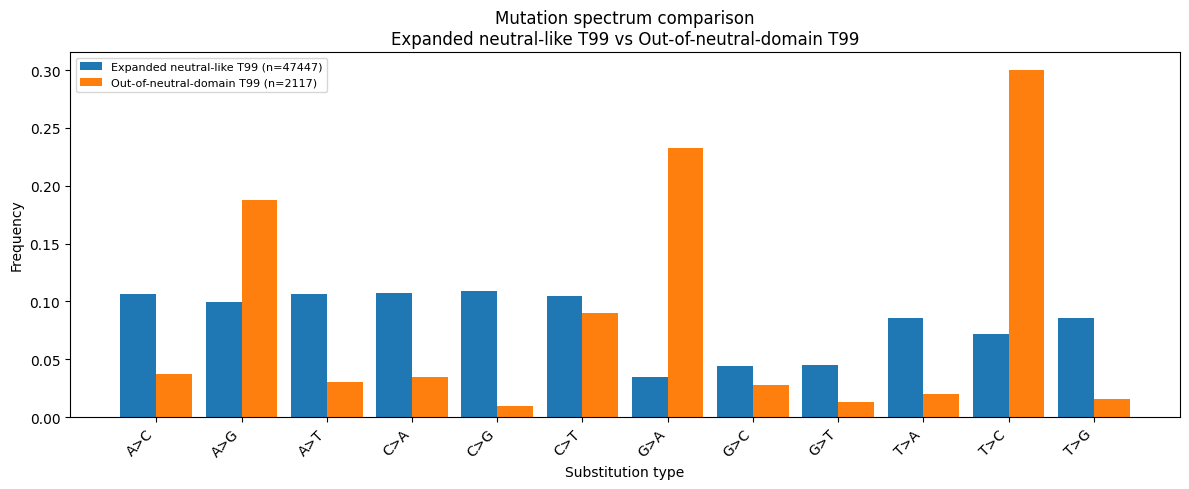

In [14]:
plot_two_group_spectrum_comparison(
    spectrum_freq,
    group_col="spectrum_group_primary_T95",
    group_1="expanded_neutral_like_T95",
    group_2="unlabeled_out_of_neutral_domain_T95",
    output_dir=PLOTS_DIR,
)

plot_two_group_spectrum_comparison(
    spectrum_freq,
    group_col="spectrum_group_strict_T95",
    group_1="strict_expanded_neutral_like_T95",
    group_2="unlabeled_out_of_neutral_domain_T95",
    output_dir=PLOTS_DIR,
)

plot_two_group_spectrum_comparison(
    spectrum_freq,
    group_col="spectrum_group_primary_T99",
    group_1="expanded_neutral_like_T99",
    group_2="unlabeled_out_of_neutral_domain_T99",
    output_dir=PLOTS_DIR,
)

In [15]:
# ============================================================
# 12. Spectrum difference plot
# ============================================================

def plot_spectrum_difference(
    spectrum_freq,
    group_col,
    reference_group,
    comparison_group,
    output_dir=None,
    show=True,
):
    ref = spectrum_freq[
        (spectrum_freq["group_col"] == group_col)
        & (spectrum_freq["group_name"] == reference_group)
    ].copy()

    comp = spectrum_freq[
        (spectrum_freq["group_col"] == group_col)
        & (spectrum_freq["group_name"] == comparison_group)
    ].copy()

    if ref.empty:
        raise ValueError(f"No spectrum found for {group_col} = {reference_group}")

    if comp.empty:
        raise ValueError(f"No spectrum found for {group_col} = {comparison_group}")

    ref = ref.set_index("substitution_type").reindex(substitution_order_12)
    comp = comp.set_index("substitution_type").reindex(substitution_order_12)

    diff = comp["frequency"].values - ref["frequency"].values

    x = np.arange(len(substitution_order_12))

    plt.figure(figsize=(11, 5))

    plt.bar(
        x,
        diff,
        color=[substitution_color_map[s] for s in substitution_order_12],
    )

    plt.axhline(0, linewidth=1)

    plt.xticks(x, substitution_order_12, rotation=45, ha="right")
    plt.ylabel("Frequency difference")
    plt.xlabel("Substitution type")

    plt.title(
        "Spectrum difference\n"
        f"{group_label_map.get(comparison_group, comparison_group)} minus "
        f"{group_label_map.get(reference_group, reference_group)}"
    )

    plt.tight_layout()

    if output_dir is not None:
        out_path = output_dir / f"spectrum_difference_{group_col}_{comparison_group}_minus_{reference_group}.png"
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        print("Saved:", out_path)

    if show:
        plt.show()
    else:
        plt.close()

Saved: ../results/mutational_spectrum_results/plots/spectrum_difference_spectrum_group_primary_T95_unlabeled_out_of_neutral_domain_T95_minus_expanded_neutral_like_T95.png


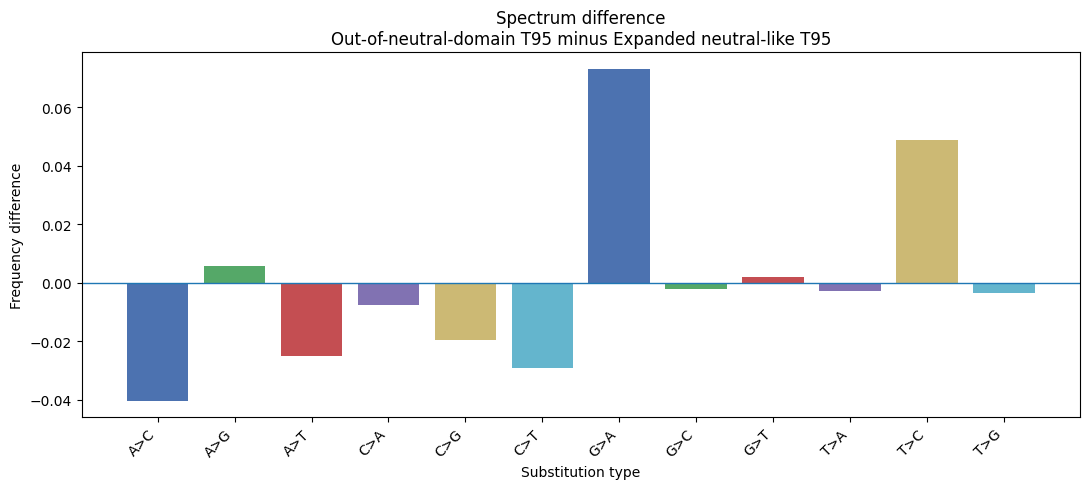

Saved: ../results/mutational_spectrum_results/plots/spectrum_difference_spectrum_group_primary_T99_unlabeled_out_of_neutral_domain_T99_minus_expanded_neutral_like_T99.png


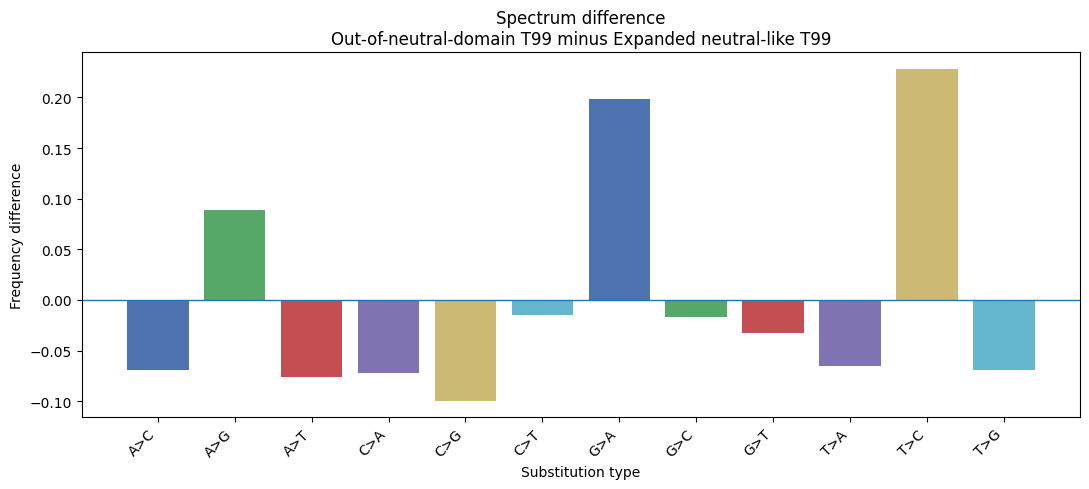

In [16]:
plot_spectrum_difference(
    spectrum_freq,
    group_col="spectrum_group_primary_T95",
    reference_group="expanded_neutral_like_T95",
    comparison_group="unlabeled_out_of_neutral_domain_T95",
    output_dir=PLOTS_DIR,
)

plot_spectrum_difference(
    spectrum_freq,
    group_col="spectrum_group_primary_T99",
    reference_group="expanded_neutral_like_T99",
    comparison_group="unlabeled_out_of_neutral_domain_T99",
    output_dir=PLOTS_DIR,
)

In [17]:
# ============================================================
# 13. Heatmap-style plot for multiple groups
# ============================================================

def plot_spectrum_heatmap(
    spectrum_freq,
    group_col,
    group_order=None,
    output_dir=None,
    show=True,
):
    plot_df = spectrum_freq[
        spectrum_freq["group_col"] == group_col
    ].copy()

    plot_df = plot_df[plot_df["group_name"] != "exclude"]

    if group_order is None:
        group_order = sorted(plot_df["group_name"].unique())

    matrix = (
        plot_df
        .pivot_table(
            index="group_name",
            columns="substitution_type",
            values="frequency",
            aggfunc="first",
        )
        .reindex(index=group_order, columns=substitution_order_12)
    )

    row_labels = [
        group_label_map.get(g, g)
        for g in matrix.index
    ]

    plt.figure(figsize=(12, max(3, 0.5 * len(group_order))))

    im = plt.imshow(matrix.values, aspect="auto")

    plt.colorbar(im, label="Frequency")

    plt.xticks(
        np.arange(len(substitution_order_12)),
        substitution_order_12,
        rotation=45,
        ha="right",
    )

    plt.yticks(
        np.arange(len(row_labels)),
        row_labels,
    )

    plt.title(f"Mutation spectrum frequencies: {group_col}")
    plt.tight_layout()

    if output_dir is not None:
        out_path = output_dir / f"spectrum_heatmap_{group_col}.png"
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        print("Saved:", out_path)

    if show:
        plt.show()
    else:
        plt.close()

Saved: ../results/mutational_spectrum_results/plots/spectrum_heatmap_spectrum_group_primary_T95.png


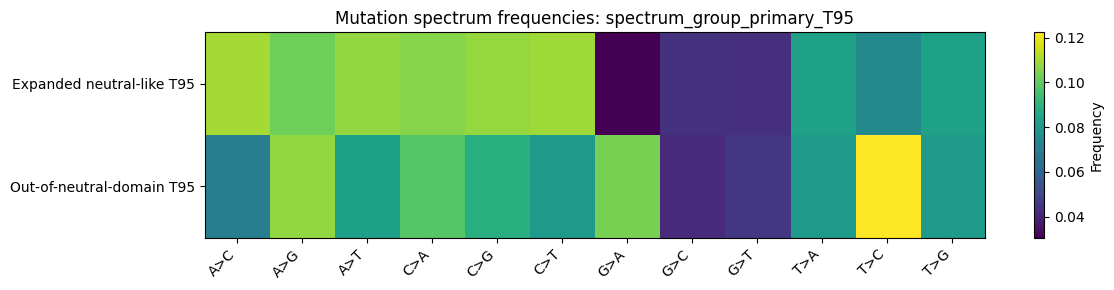

Saved: ../results/mutational_spectrum_results/plots/spectrum_heatmap_spectrum_group_posthoc.png


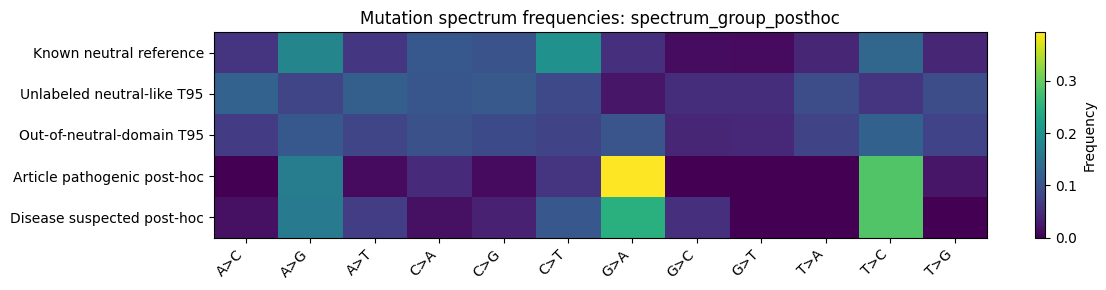

In [18]:
plot_spectrum_heatmap(
    spectrum_freq,
    group_col="spectrum_group_primary_T95",
    group_order=[
        "expanded_neutral_like_T95",
        "unlabeled_out_of_neutral_domain_T95",
    ],
    output_dir=PLOTS_DIR,
)

plot_spectrum_heatmap(
    spectrum_freq,
    group_col="spectrum_group_posthoc",
    group_order=[
        "known_neutral_reference",
        "unlabeled_neutral_like_T95",
        "unlabeled_out_of_neutral_domain_T95",
        "article_pathogenic_posthoc",
        "disease_suspected_posthoc",
    ],
    output_dir=PLOTS_DIR,
)

In [19]:
# ============================================================
# 14. Multi-panel spectra figure
# ============================================================

def plot_multipanel_spectra(
    spectrum_freq,
    group_col,
    group_order,
    output_dir=None,
    show=True,
):
    n_groups = len(group_order)

    fig, axes = plt.subplots(
        n_groups,
        1,
        figsize=(12, 3 * n_groups),
        sharex=True,
    )

    if n_groups == 1:
        axes = [axes]

    max_freq = 0

    prepared = {}

    for group_name in group_order:
        sub = spectrum_freq[
            (spectrum_freq["group_col"] == group_col)
            & (spectrum_freq["group_name"] == group_name)
        ].copy()

        if sub.empty:
            raise ValueError(f"No spectrum found for {group_col} = {group_name}")

        sub = sub.set_index("substitution_type").reindex(substitution_order_12)
        prepared[group_name] = sub
        max_freq = max(max_freq, sub["frequency"].max())

    x = np.arange(len(substitution_order_12))

    for ax, group_name in zip(axes, group_order):
        sub = prepared[group_name]

        n_variants = int(sub["n_variants"].dropna().iloc[0])

        ax.bar(
            x,
            sub["frequency"].values,
            color=[substitution_color_map[s] for s in substitution_order_12],
        )

        ax.set_ylabel("Frequency")
        ax.set_ylim(0, max_freq * 1.15)

        ax.set_title(
            f"{group_label_map.get(group_name, group_name)} (n={n_variants})",
            loc="left",
            fontsize=11,
        )

    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(substitution_order_12, rotation=45, ha="right")
    axes[-1].set_xlabel("Substitution type")

    fig.suptitle(f"12-channel mtDNA mutation spectra: {group_col}", y=1.01)
    plt.tight_layout()

    if output_dir is not None:
        out_path = output_dir / f"multipanel_spectra_{group_col}.png"
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        print("Saved:", out_path)

    if show:
        plt.show()
    else:
        plt.close()

Saved: ../results/mutational_spectrum_results/plots/multipanel_spectra_spectrum_group_primary_T95.png


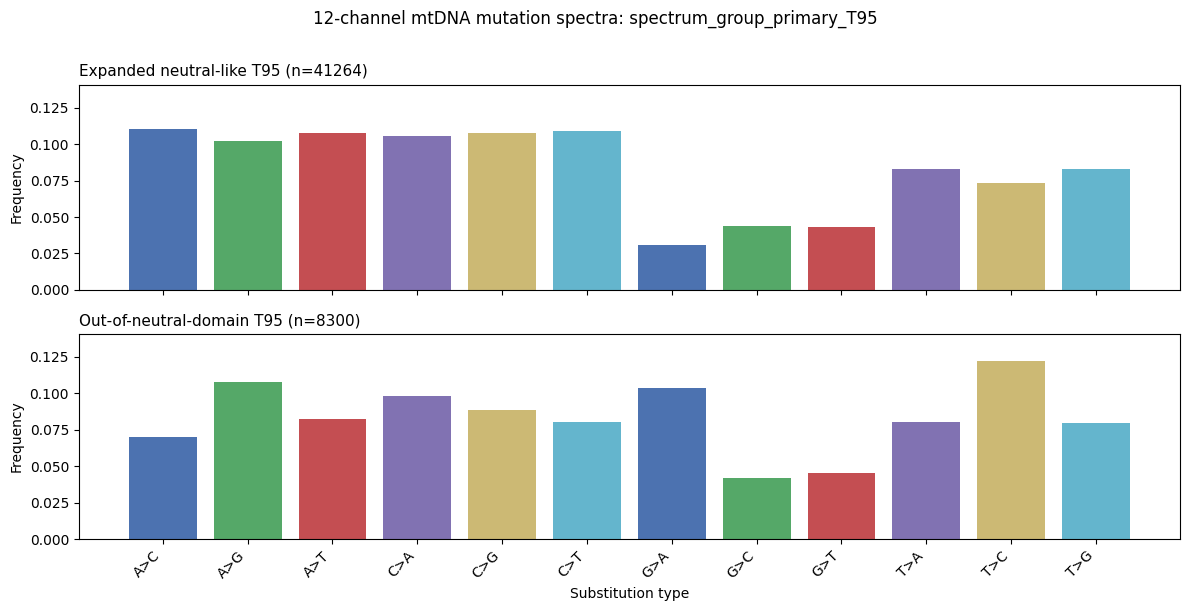

Saved: ../results/mutational_spectrum_results/plots/multipanel_spectra_spectrum_group_posthoc.png


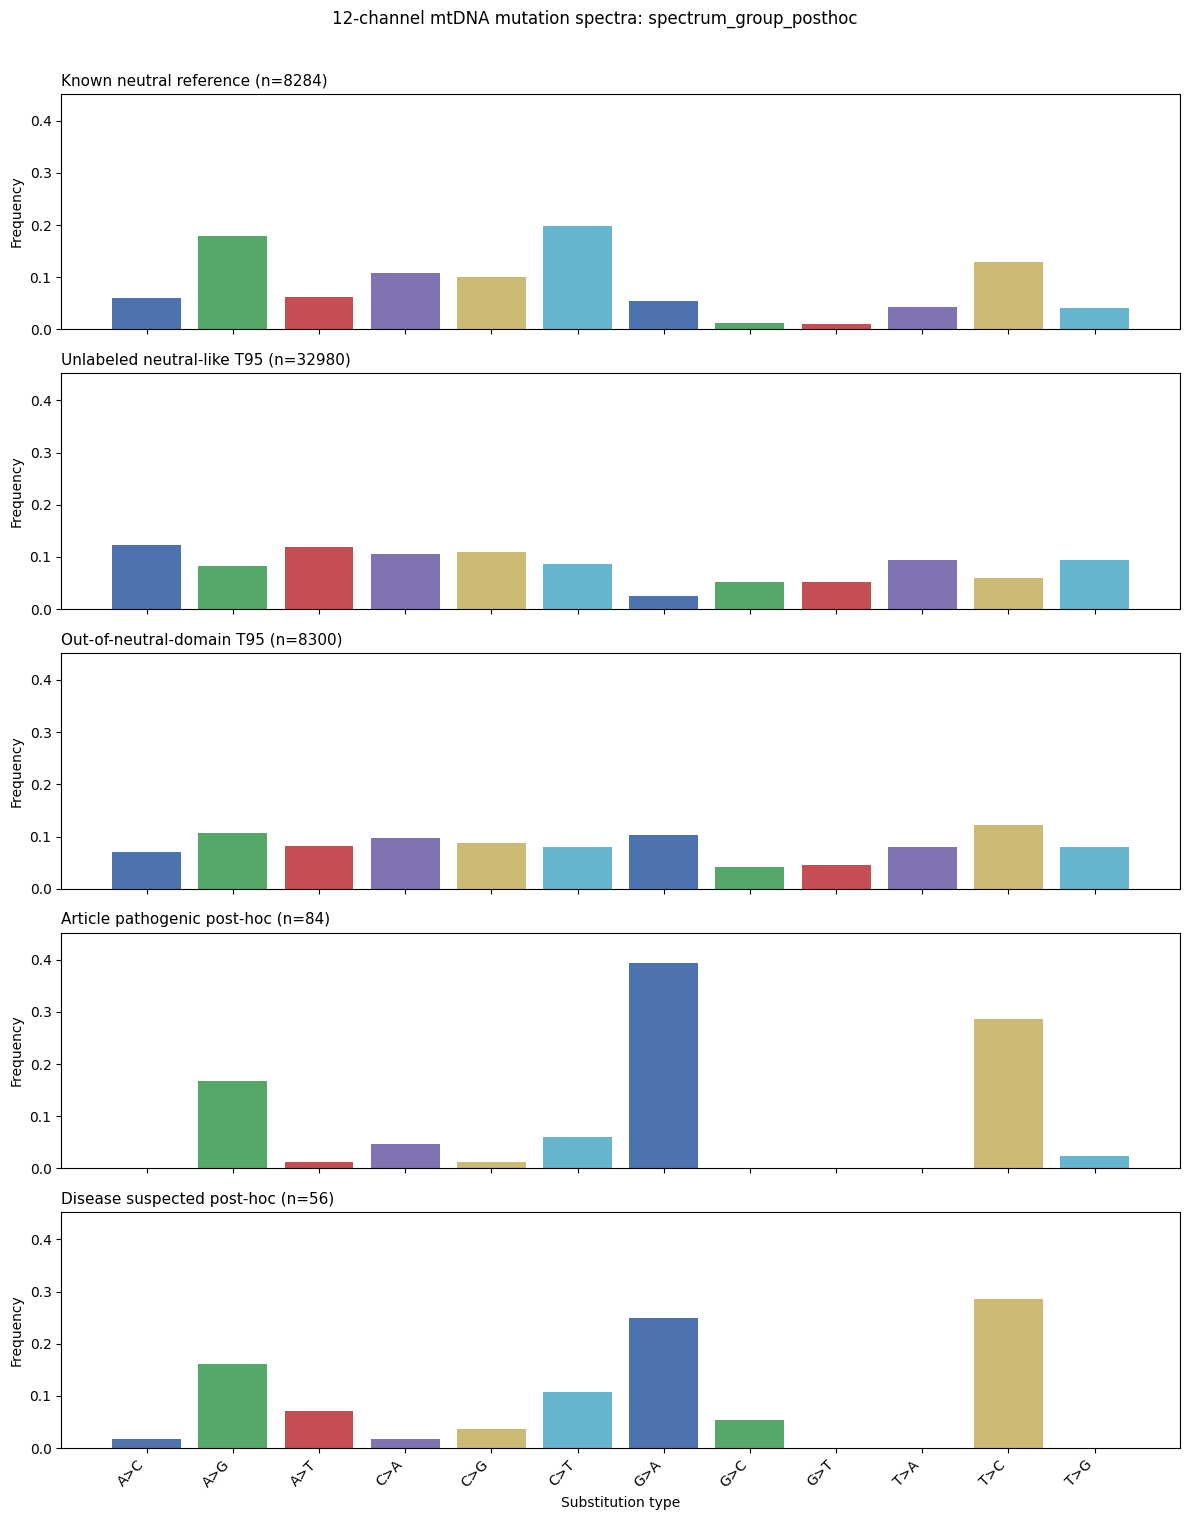

In [20]:
plot_multipanel_spectra(
    spectrum_freq,
    group_col="spectrum_group_primary_T95",
    group_order=[
        "expanded_neutral_like_T95",
        "unlabeled_out_of_neutral_domain_T95",
    ],
    output_dir=PLOTS_DIR,
)

plot_multipanel_spectra(
    spectrum_freq,
    group_col="spectrum_group_posthoc",
    group_order=[
        "known_neutral_reference",
        "unlabeled_neutral_like_T95",
        "unlabeled_out_of_neutral_domain_T95",
        "article_pathogenic_posthoc",
        "disease_suspected_posthoc",
    ],
    output_dir=PLOTS_DIR,
)